#Transformers: Applications in Language and Communication (INFOMTALC)

## Midterm Take-Home Exam

### Deadline: Sunday March 8, 2026, 23:59 CET

The midterm take-home exam for the INFOMTALC Transformers course consists of **three** questions. Per question, the following points can be scored maximally:

* Question 1: 50 points
* Question 2: 25 points
* Question 3: 25 points

The sum of obtained scores is then divided by 10.

All questions assume the use of Google Colab. Question 1 is handled in a different notebook from this one (the link is given below). Questions 2 and 3 are in this notebook. You submit your copy of this notebook with your solutions and discussions for questions 2 and 3 as an .ipynb file on Brightspace.

#Assignment 1

This assignment is introduced separately in a different Notebook:

https://colab.research.google.com/drive/1xexTvv_pz0NT8Zyswq6AUOpeDPBzAdH3?usp=sharing

Follow the instructions there, and **do not include anything** of your solution(s) for assignment 1 into this notebook.

# Assignment 2

This question is about finding meaningful attention weights in a pre-trained Transformer. We are going to use the `bertviz` library to visualize internals of [bert-base-uncased](https://huggingface.co/google-bert/bert-base-uncased), a pretrained BERT model. We are going to input a short two-sentence text into the model, activating all 12 attention layers:

> *The gates were guarded by two soldiers. One of them was suddenly attacked by two wolves.*

In this two sentences, many words have relationships with other words. One type of relation is co-reference: a pair of words that both refer to the same entity, such as 'soldiers' and 'them'. Or could 'them' also refer to 'gates'? As human readers we usually do not notice such ambiguities. Can we trace how this works in a pre-trained Transformer? Let's load the encoder and start up `bertviz` with these two sentences as input.


In [5]:
!pip install bertviz

# Load model and retrieve attention weights

from bertviz import head_view, model_view
from transformers import BertTokenizer, BertModel

model_version = 'bert-base-uncased'
model = BertModel.from_pretrained(model_version, output_attentions=True)
tokenizer = BertTokenizer.from_pretrained(model_version)
sentence_a = "The gates were guarded by two soldiers."
sentence_b = "One of them was suddenly attacked by two wolves."
inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt', padding=True, truncation=True)
input_ids = inputs['input_ids']
token_type_ids = inputs['token_type_ids']
attention = model(input_ids, token_type_ids=token_type_ids)[-1]
sentence_b_start = token_type_ids[0].tolist().index(1)
input_id_list = input_ids[0].tolist() # Batch index 0
tokens = tokenizer.convert_ids_to_tokens(input_id_list)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The visualization shows 12 layers (0-11), selectable via the left-hand pull-down menu. The attention direction in the right-hand pull-down menu can best be kept at "All". The attention heads for each layer are represented by the 12 colored boxes that can be selected (full color) and de-selected (lighter color) by clicking on them. To zoom in on single attention heads in this assignment, deselect all other heads so that only one head is selected at a time.

In Seminar 2, we found out that the sixth (brown-colored) attention head of layer 5 is sensitive to co-reference. Verify this by selecting this layer and head and move your mouse over 'them': the attention head is actually divided between whether 'them' refers to the 'two soldiers' or 'the gates'.

Find *at least two other attention heads* that show a sensitivity for a strong interpretable relationship (visible by a strong between a pair or other combination of words. Specify the attention head, the words, and explain what relation is being detected by the attention head.

Possible relations can be

* **grammatical**: 'gates' is the subject of the verb 'were'; and because of grammatical agreement in English between subject and verb, both have a plural form)
* **discourse-level**: 'them' refers to 'soldiers' in a co-reference relation; both words refer to the same entities. Or does 'them' refer to 'gates'?
* **semantic**: a 'gate' can refer to an airport gate or a type of logical circuit, but here it refers to the barred entrance in a wall, thanks to its co-occurrence with 'guarded' and 'soldiers'.

*Hint*: often, abstract relations between words like grammatical and semantic relations are represented more frequently at layers in the middle and higher up in the attention layer stack.


In [6]:
head_view(attention, tokens, sentence_b_start)

RuntimeError: stack expects a non-empty TensorList

*Your answers here*

#Assignment 3

In this assignment you are going to use decoder Transformer models to generate short texts.

First, we need to install some packages. Also, make sure your Colab Runtime is set to a GPU (we suggest A100).

In [7]:
!pip install -U bitsandbytes accelerate

Let's load a model. As an example we use the small version of GPT-2.

You can also explore other models, including newer and bigger ones if you can make them fit into a Colab (e.g. you can use 8-bit quantization to load the XL version of GPT-2).

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Users\Gabri\Documents\!Utrecht University\MSc - Applied Data Science\Period 3\Transformers\!MIDTERM\venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gabri\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Here is an example of prompting the model:

In [5]:
from transformers import GenerationConfig

def prompting(input_text, model, tokenizer, generation_config):
    input_ids = tokenizer(input_text, return_tensors="pt").to("cuda")
    outputs = model.generate(**input_ids, generation_config=generation_config)
    return tokenizer.decode(outputs[0])

example_input = "I am an applied data science student taking the midterm exam of Transformers course. I"
generation_config = GenerationConfig(max_new_tokens=50, do_sample=True, temperature=1.0, pad_token_id=tokenizer.eos_token_id)

example_generation = prompting(example_input, model, tokenizer, generation_config)
print(example_generation)

I am an applied data science student taking the midterm exam of Transformers course. I will be going into the program with my partner, the graduate student, and will be starting the course in October. I started as a data scientist for Gartner, I am an Applied Data Science Student taking the midterm exam of Transformers course. I


This assignment zooms in on the effect of the **temperature** hyperparameter. We came across temperature before when in the second seminar we explored the `pytorch` implementation of a fully functional decoder Transformer, miniGPT.

Temperature (T) is an important hyperparameter of a decoder. It can warp the token probability distribution of a next-token prediction in two directions. T=1 represents the middle point between these directions. With colder temperatures, 0 < T < 1, probabilities are more extremely drawn towards the most likely tokens, and less likely tokens receive even lower probabilities. At higher temperatures, T > 1, the probability distribution becomes flatter; tokens become increasingly likely. The function below generates a figure that illustrates this with T = 0.5, T = 1, and T = 2.

Intuitively, lower temperatures lead to conservative next-word prediction, while higher temperatures lead to wildly unpredictable next tokens.

Often, T is set at 0.7 or 0.8 in encoders such as ChatGPT.

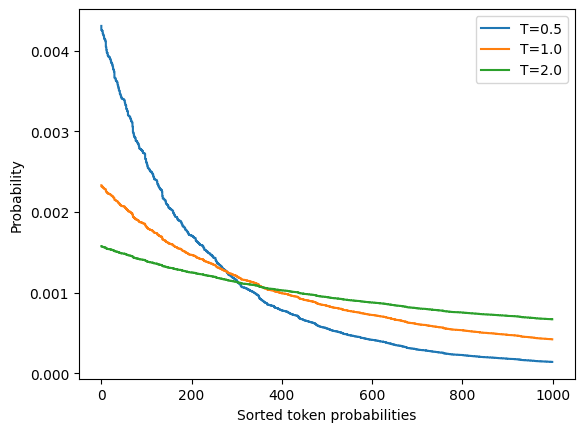

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

Temperature steers the way that **sampling** works, which is the most basic generation strategy used by token-generating decoders: when selecting the next token to generate, we sample from the predicted token distribution, weighted by the token probabilities (the logits in the output layer of the decoder). Chances are high that we choose a token with a high probability, but not necessary always the most likely token. Temperature, as explained, warps this probability space.

In the cell below, you will find temperature as a parameter that you can adapt. The cell also contains code for computing the log probability of the generated output sequence. This is the sum of log(p), where p is the probability assigned to the model to each generated token. If a token is predicted with 100% likelihood, log(p)=0 for that token; lower probabilities lead to increasingly negative values of log(p). In other words, the logprob of a sequence is generally a negative number, and less negative values closer to 0 indicate more 'certainty' in the generated text.

In [7]:
import torch.nn.functional as F

def sequence_logprob(sequence, model, tokenizer, device='cuda'):
    # 1. Tokenize the sequence
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True)
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # 2. Pass through the model in evaluation mode
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

    # 3. Extract logits
    logits = outputs.logits

    # 4. Calculate log softmax to get log probabilities
    log_probs = F.log_softmax(logits, dim=-1)

    # 5. Get the log probability for each predicted next token
    # We need to shift the input_ids to align with log_probs
    # log_probs[0, :-1] gives probabilities for tokens up to the second to last
    # input_ids[0, 1:] gives the actual next tokens (shifted by one)
    predicted_log_probs = torch.gather(log_probs[:, :-1, :], -1, input_ids[:, 1:].unsqueeze(-1)).squeeze(-1)

    # 6. Sum these log probabilities
    # We ignore the first token's probability since it's conditioned on nothing
    # or the start of sentence token, and the last token's probability isn't fully predicted yet
    # The length of the sequence is len(input_ids[0]) - 1 for actual tokens after start_token
    total_log_prob = predicted_log_probs.sum().item()

    return total_log_prob

prompt = "Once upon a time"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

# Generate text with high temperature
outputs = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=50,
    do_sample=True,
    temperature=2.0,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)

# Compute and print logprob
logp = sequence_logprob(generated_text, model, tokenizer, device=device)
print(f"Log probability of the generated sequence: {logp}")

Once upon a time of need and a need he asked for advice from his Master; he offered that he might lead those who knew good and evil people his way and his best way.[33] (De Civ.: A Crit, 17–7.) We know of no
Log probability of the generated sequence: -214.12612915039062


For the assignment you first **write 10 input prompts (e.g. half-finished sentences) yourself**.

Then, for each input prompt, you generate outputs for a range of temperature values, starting from 0.1 up to 2.5 in steps of 0.1. You record the logprob values of each of these 25 outputs. In a graph, with temperature on the x-axis and logprob on the y-axis, you **plot the average logprob of all generated texts based on the 10 input prompts, for each temperature value**.

Then, you

* **discuss what you observe in the graph**;
* **discuss why chatbots like OpenAI's GPT set temperature at 0.7 or 0.8, when these do not represent optimal points for logprob scores.**

In answering the second question you may use additional code that shows, for one prompt, different outputs generated with different temperatures, for illustration and/or qualitative analysis supporting your answer.

In [2]:
# Imports for Assignment 3
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
from wordcloud import WordCloud

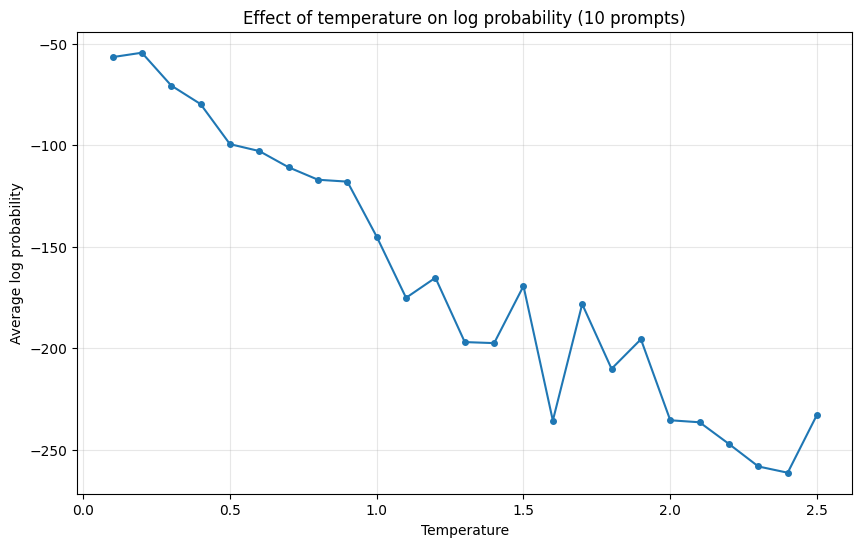

In [ ]:
prompts = [
    "The climber desperately reached for the ...",
    "Le verre est sur la ...",
    "The maestro conducted the ...",
    "La terre est ...",
    "On the shoulders of ...",
    "The greatest man in history was ...",
    "Your opinions don't ...",
    "Le chat est ...",
    "He drank his ...",
    "Les chevaliers trinquèrent leurs ...",
]

temperatures = np.arange(0.1, 2.6, 0.1)
avg_logprobs = []

for i, temp in enumerate(temperatures):
    logprobs_for_temp = []
    for prompt in prompts:
        generation_config = GenerationConfig(
            max_new_tokens=50,
            do_sample=True,
            temperature=float(temp),
            pad_token_id=tokenizer.eos_token_id,
        )
        generated_text = prompting(prompt, model, tokenizer, generation_config)
        logp = sequence_logprob(generated_text, model, tokenizer, device=device)
        logprobs_for_temp.append(logp)
    avg_logprobs.append(np.mean(logprobs_for_temp))

avg_logprobs = np.array(avg_logprobs)

plt.figure(figsize=(10, 6))
plt.plot(temperatures, avg_logprobs, marker="o", markersize=4)
plt.xlabel("Temperature")
plt.ylabel("Average log probability")
plt.title("Effect of temperature on log probability (10 prompts)")
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# One prompt, three temperatures: show how output changes (for the discussion)
example_prompt = "The greatest man in history was "
for temp in [0.1, 0.7, 2.0]:
    gen_config = GenerationConfig(max_new_tokens=40, do_sample=True, temperature=temp, pad_token_id=tokenizer.eos_token_id)
    text = prompting(example_prompt, model, tokenizer, gen_config)
    print(f"T = {temp}: {text}\n")

T = 0.1: The greatest man in history was  a man who was a man who was a man who was a man who was a man who was a man who was a man who was a man who was a man who was a man who

T = 0.7: The greatest man in history was  made by a man who gave his life for the cause of it," says Dr. J. R. Smith, senior fellow at the American Enterprise Institute. "He was willing to sacrifice his life

T = 2.0: The greatest man in history was nhc by his wife, he couldn't come at times. His children had many children and a father in charge only. In contrast, all women are able to choose to stay put



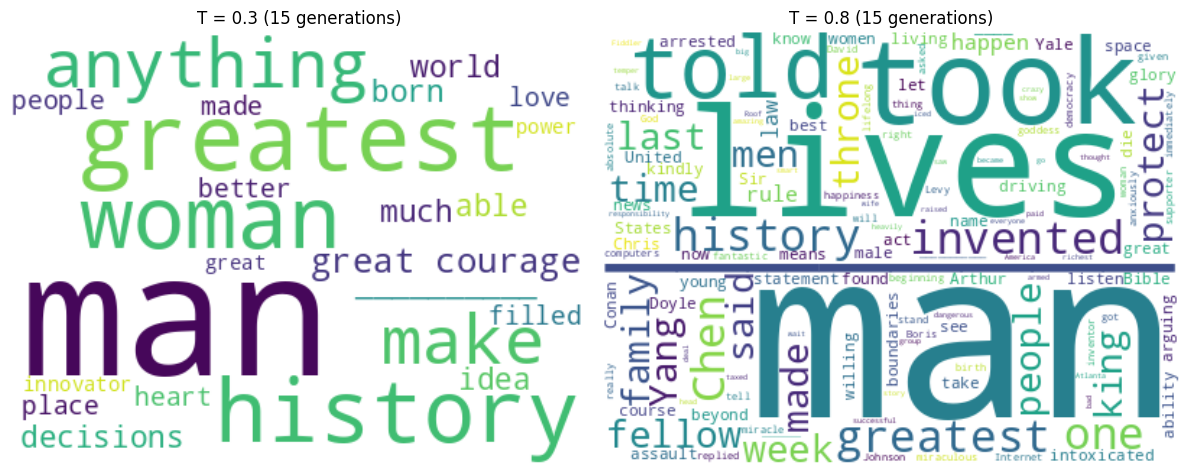

In [12]:
# Two word clouds: same prompt at low vs high temperature (LLM output only)
# Uses GPT-2 (causal LM). If model is from Assignment 2 (BERT), we load GPT-2 here.
device = "cuda" if torch.cuda.is_available() else "cpu"
if not hasattr(model, "generate"):
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

prompt_wc = "The greatest man in history was "
n_gen = 15

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (temp, label) in zip(axes, [(0.3, "T = 0.3"), (0.8, "T = 0.8")]):
    texts = []
    for _ in range(n_gen):
        inputs = tokenizer(prompt_wc, return_tensors="pt").to(device)
        out = model.generate(**inputs, max_new_tokens=40, do_sample=True, temperature=temp, pad_token_id=tokenizer.eos_token_id)
        full = tokenizer.decode(out[0])
        rest = full[len(prompt_wc):].strip() if full.startswith(prompt_wc) else full
        texts.append(rest)
    combined = " ".join(texts)
    wc = WordCloud(width=400, height=300, background_color="white").generate(combined)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label} ({n_gen} generations)")
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Choice of prompts and use of French

I used a mix of English and French half-finished sentences. I included French (I am French–Brazilian) to make the prompts original and to vary what the model sees. The assignment only asks for our own prompts, and the effect of temperature on log probability should hold either way. The four French prompts with English translations:

- *Le verre est sur la ...* → The glass is on the ...
- *La terre est ...* → The earth is ...
- *Le chat est ...* → The cat is ...
- *Les chevaliers trinquèrent leurs ...* → The knights clinked their ...

#### What we observe in the graph

As temperature goes from 0.1 to 2.5, the average log probability goes down (gets more negative). That makes sense: at low temperature the model mostly picks high-probability tokens, so the sequence has a high (less negative) log prob. When we raise temperature, the distribution over next tokens gets flatter, so the model samples lower-probability tokens more often and the average log prob drops.

The curve is smooth at low temperatures but starts to jump around from about 1.1 onwards. I think that's because at high temperature the outputs are much more variable (each run can land on very different tokens), and we only average over 10 prompts per temperature, so we get noise. Some of my prompts also had many plausible completions (e.g. "The greatest man in history was …", "La terre est …"), so the model's distribution was already spread out; when we flatten it more with temperature, whether we happen to sample a higher- or lower-probability sequence is almost random, and that shows up as the peaks and troughs.

At very low temperature (0.1) the model got stuck in a loop: for "The greatest man in history was " it kept producing "a man who was a man who was a man who…". So we get a high log probability but the text is useless, which illustrates why very low temperature is not a good default despite the favourable log probability.

The simplified wordcloud above (T = 0.3 vs T = 0.8, 15 generations each from the same prompt) illustrates this visually: at low temperature a few words dominate and the output is more repetitive, while at higher temperature the vocabulary is more diverse and spread out.

#### Why chatbots set temperature around 0.7 or 0.8

Chatbots don't try to maximise log probability; they want text that's coherent, not repetitive, and useful. If temperature is too low, we get the kind of repetitive loop I saw at 0.1. If it's too high, the output becomes random and incoherent (like in the T = 2.0 example). Around 0.7 or 0.8 you get a middle ground: the model still prefers likely tokens so the text stays coherent, but there's enough randomness to avoid loops and to get some variety between turns. So 0.7–0.8 is a practical default: it's not the best for log probability (our graph shows that), but it's better for how the chatbot actually feels to use - which is exactly what Holtzman et al. (2020) document systematically.

Having looked a little bit into the literature, I found that *The Curious Case of Neural Text Degeneration* (ICLR 2020) is one of the most cited papers on this topic. They show that greedy and low-temperature decoding often produce bland or repetitive text that gets stuck in loops. So the 0.7 to 0.8 default fits with what people have found in practice.

#### References

- Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. ICLR 2020. https://openreview.net/forum?id=rygGQyrFvH

